# Classifieur de Validité des Phrases de Trajet

Ce notebook entraîne un classifieur binaire pour détecter si une phrase est **valide** (contient une intention de trajet) ou **invalide** (hors contexte).

## Objectif
Créer un système qui filtre les phrases avant le traitement NLP, permettant de ne traiter que les phrases pertinentes.

## Structure
1. **Configuration & Imports** - Paramètres centralisés et dépendances
2. **Chargement des Données** - Lecture et exploration du dataset
3. **Preprocessing** - Nettoyage et vectorisation
4. **Entraînement avec Checkpoints** - Modèles avec sauvegarde périodique
5. **Évaluation** - Métriques et analyse des erreurs
6. **Sauvegarde du Modèle Final** - Export pour production


## 1. Configuration & Imports

### Configuration centralisée

**Objectif** : Définir tous les paramètres en un seul endroit pour faciliter les expérimentations.

**Ce qu'on fait** :
- Définir les chemins vers les fichiers et dossiers (dataset, modèles, résultats, checkpoints)
- Configurer les paramètres du dataset (limite, seed pour reproductibilité)
- Définir comment diviser les données (train/validation/test)
- Configurer le preprocessing TF-IDF (comment transformer le texte en nombres)
- Choisir le type de modèle et ses hyperparamètres
- Activer/désactiver les checkpoints

**Pourquoi** : Avoir tous les paramètres au même endroit permet de modifier facilement l'expérience sans chercher dans tout le code.


In [1]:
# ============================================================================
# CONFIGURATION - Modifier ces paramètres selon vos besoins
# ============================================================================

import os
from pathlib import Path
from datetime import datetime

# Chemins des fichiers
# Dans un notebook Jupyter, le répertoire courant est généralement le dossier du notebook
# On remonte d'un niveau pour accéder à la racine du projet
import os
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
DATASET_PATH = PROJECT_ROOT / "dataset" / "json" / "dataset.jsonl"
MODELS_DIR = PROJECT_ROOT / "models" / "baseline"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
LOGS_DIR = PROJECT_ROOT / "logs" / "training"

# Créer les dossiers si nécessaire
for dir_path in [MODELS_DIR, CHECKPOINTS_DIR, RESULTS_DIR, LOGS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Paramètres du dataset
DATASET_LIMIT = None  # None pour utiliser tout le dataset, ou int pour limiter
RANDOM_SEED = 42

# Paramètres de split
TEST_SIZE = 0.2
VAL_SIZE = 0.1  # Proportion du train qui devient validation
STRATIFY = True  # Maintenir la distribution des classes

# Paramètres de preprocessing
LOWERCASE = False  # Garder la casse pour préserver les variations
MIN_DF = 2  # Minimum document frequency pour TF-IDF
MAX_DF = 0.95  # Maximum document frequency
MAX_FEATURES = 10000  # Nombre maximum de features TF-IDF
NGRAM_RANGE = (1, 2)  # Unigrammes et bigrammes

# Paramètres d'entraînement
MODEL_TYPE = "logistic_regression"  # Options: "logistic_regression", "svm", "random_forest", "gradient_boosting"
SAVE_CHECKPOINTS = True  # Activer les checkpoints
CHECKPOINT_INTERVAL = 0.1  # Sauvegarder tous les 10% de l'entraînement (pour cross-validation)
EARLY_STOPPING = False  # Early stopping (si supporté par le modèle)
EARLY_STOPPING_PATIENCE = 5  # Nombre d'itérations sans amélioration

# Paramètres spécifiques par modèle
MODEL_CONFIGS = {
    "logistic_regression": {
        "C": 1.0,
        "max_iter": 1000,
        "solver": "lbfgs",
        "class_weight": "balanced"  # Gérer le déséquilibre des classes
    },
    "svm": {
        "C": 1.0,
        "kernel": "linear",
        "class_weight": "balanced"
    },
    "random_forest": {
        "n_estimators": 100,
        "max_depth": 20,
        "class_weight": "balanced",
        "random_state": RANDOM_SEED
    },
    "gradient_boosting": {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 5,
        "random_state": RANDOM_SEED
    }
}

# Métadonnées
EXPERIMENT_NAME = f"validity_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
VERSION = "v1"

print(f"✅ Configuration chargée")
print(f"   Dataset: {DATASET_PATH}")
print(f"   Modèle: {MODEL_TYPE}")
print(f"   Expérience: {EXPERIMENT_NAME}")


✅ Configuration chargée
   Dataset: /workspace/dataset/json/dataset.jsonl
   Modèle: logistic_regression
   Expérience: validity_classifier_20260104_184906


### Imports

**Objectif** : Charger toutes les bibliothèques nécessaires pour le machine learning et la visualisation.

**Ce qu'on fait** :
- **pandas/numpy** : Manipulation des données (DataFrames, arrays)
- **matplotlib/seaborn** : Création de graphiques et visualisations
- **scikit-learn** : Algorithmes de machine learning (Logistic Regression, SVM, etc.) et outils (train_test_split, métriques)
- **joblib** : Sauvegarde/chargement des modèles entraînés
- **json** : Lecture/écriture de fichiers JSON

**Pourquoi** : Ces bibliothèques fournissent toutes les fonctions nécessaires pour charger les données, entraîner des modèles, évaluer les performances et sauvegarder les résultats.


In [2]:
# Standard libraries
import json
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Essayer différents styles selon la version de matplotlib
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')  # Style de fallback
sns.set_palette("husl")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Utilitaires
import joblib
from tqdm import tqdm

print("✅ Imports terminés")


✅ Imports terminés


## 2. Chargement des Données

**Objectif** : Lire le dataset JSONL et le convertir en DataFrame pandas pour pouvoir le manipuler facilement.

**Ce qu'on fait** :
- Créer une fonction `load_jsonl()` qui lit le fichier ligne par ligne
- Chaque ligne du JSONL contient un objet JSON avec : `sentence`, `departure`, `arrival`, `is_valid`
- Convertir toutes les lignes en un DataFrame pandas
- Afficher un aperçu des premières lignes pour vérifier que tout est correct

**Pourquoi** : Le format JSONL (JSON Lines) est pratique pour stocker de grandes quantités de données. Le DataFrame pandas permet ensuite de manipuler facilement les données avec des opérations comme filtrer, grouper, etc.


In [3]:
# Chargement du dataset JSONL
def load_jsonl(file_path, limit=None):
    """Charge un fichier JSONL et retourne un DataFrame."""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            if line.strip():
                data.append(json.loads(line))
    return pd.DataFrame(data)

# Charger les données
print(f"📂 Chargement du dataset depuis {DATASET_PATH}...")
df = load_jsonl(DATASET_PATH, limit=DATASET_LIMIT)
print(f"✅ {len(df)} phrases chargées")

# Afficher les premières lignes
print("\n📊 Aperçu des données:")
print(df.head())


📂 Chargement du dataset depuis /workspace/dataset/json/dataset.jsonl...
✅ 10000 phrases chargées

📊 Aperçu des données:
                                            sentence  \
0  Trajet direct la gare de Golfe Juan Vallauris ...   
1                 La SNCF annoncce des perturbations   
2                Voyage avec vélo Duye la gare de rs   
3  depui Saint-Maurice-de-Beynost vers Lavoûte-su...   
4                  je veu alé a l'aéroport de chanac   

                  departure              arrival  is_valid  
0      Golfe Juan Vallauris  Saint-Martin-d'Oney         1  
1                      None                 None         0  
2                     Druye                  Ors         1  
3  Saint-Maurice-de-Beynost    Lavoûte-sur-Loire         1  
4                      None               Chanac         1  


### Exploration des données

**Objectif** : Comprendre les caractéristiques du dataset avant de commencer l'entraînement.

**Ce qu'on fait** :
1. **Statistiques de base** : Compter combien de phrases sont valides vs invalides, calculer les pourcentages
2. **Analyse de longueur** : Mesurer la longueur des phrases (moyenne, médiane, min, max) pour voir la variabilité
3. **Visualisations** :
   - Graphique en barres montrant la distribution des classes (valide/invalide)
   - Histogramme montrant la distribution des longueurs de phrases
4. **Exemples** : Afficher quelques exemples de phrases valides et invalides pour comprendre le contenu

**Pourquoi** : Cette exploration permet de :
- Détecter des problèmes (déséquilibre de classes, phrases trop courtes/longues)
- Comprendre la nature des données
- Décider si des ajustements sont nécessaires (par exemple, si les classes sont très déséquilibrées)


📈 Statistiques du dataset:
   Total de phrases: 10000
   Phrases valides (is_valid=1): 6983 (69.8%)
   Phrases invalides (is_valid=0): 3017 (30.2%)

📏 Longueur des phrases:
   Moyenne: 55.7 caractères
   Médiane: 56.0 caractères
   Min: 1 caractères
   Max: 157 caractères


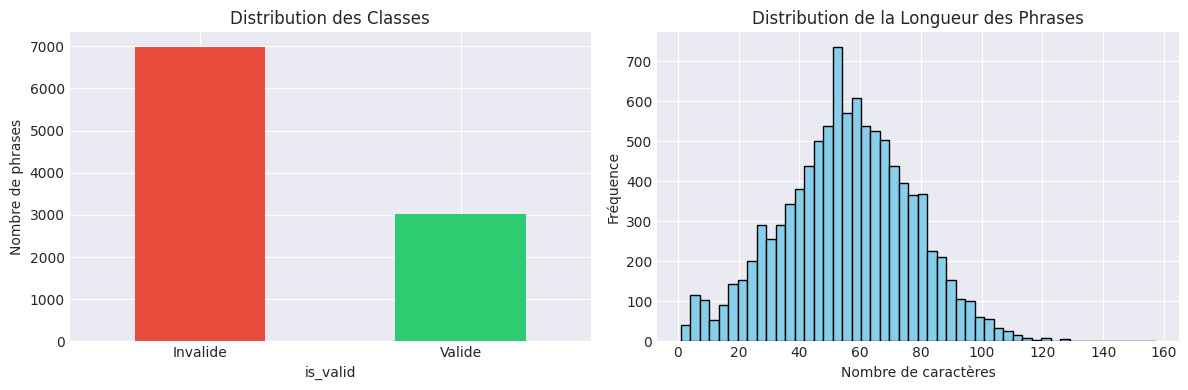


📝 Exemples de phrases valides:
   1. Trajet direct la gare de Golfe Juan Vallauris saint-martin-d'oney
   2. Voyage avec vélo Duye la gare de rs
   3. depui Saint-Maurice-de-Beynost vers Lavoûte-sur--Loire stp vite

📝 Exemples de phrases invalides:
   1. La SNCF annoncce des perturbations
   2. Je dois me redre a Villefictive deuis la gare de La Défense Grane Arhe RER E
   3. Dans cette fiction, ils voyagent de Bergues à port de petit vaux


In [4]:
# Statistiques de base
print("📈 Statistiques du dataset:")
print(f"   Total de phrases: {len(df)}")
print(f"   Phrases valides (is_valid=1): {df['is_valid'].sum()} ({df['is_valid'].mean()*100:.1f}%)")
print(f"   Phrases invalides (is_valid=0): {(df['is_valid']==0).sum()} ({(df['is_valid']==0).mean()*100:.1f}%)")

# Longueur des phrases
df['sentence_length'] = df['sentence'].str.len()
print(f"\n📏 Longueur des phrases:")
print(f"   Moyenne: {df['sentence_length'].mean():.1f} caractères")
print(f"   Médiane: {df['sentence_length'].median():.1f} caractères")
print(f"   Min: {df['sentence_length'].min()} caractères")
print(f"   Max: {df['sentence_length'].max()} caractères")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
df['is_valid'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution des Classes')
axes[0].set_xlabel('is_valid')
axes[0].set_ylabel('Nombre de phrases')
axes[0].set_xticklabels(['Invalide', 'Valide'], rotation=0)

# Distribution de la longueur des phrases
df['sentence_length'].hist(bins=50, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Distribution de la Longueur des Phrases')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# Exemples de phrases
print("\n📝 Exemples de phrases valides:")
valid_examples = df[df['is_valid'] == 1]['sentence'].head(3)
for i, ex in enumerate(valid_examples, 1):
    print(f"   {i}. {ex}")

print("\n📝 Exemples de phrases invalides:")
invalid_examples = df[df['is_valid'] == 0]['sentence'].head(3)
for i, ex in enumerate(invalid_examples, 1):
    print(f"   {i}. {ex}")


## 3. Preprocessing

**Objectif** : Préparer les données pour l'entraînement en les divisant en ensembles et en les transformant en format numérique.

**Ce qu'on fait** :
1. **Séparation des features et labels** : Extraire les phrases (X) et les labels is_valid (y)
2. **Division train/validation/test** : Séparer les données en 3 ensembles :
   - **Train** (70%) : Pour entraîner le modèle
   - **Validation** (10%) : Pour ajuster les hyperparamètres et évaluer pendant l'entraînement
   - **Test** (20%) : Pour évaluer les performances finales (jamais utilisé pendant l'entraînement)
3. **Stratification** : Maintenir la même proportion de classes valides/invalides dans chaque ensemble

**Pourquoi** : 
- Le split permet d'évaluer si le modèle généralise bien (ne mémorise pas juste les données d'entraînement)
- La stratification garantit que chaque ensemble a la même distribution de classes, ce qui est important pour un entraînement équilibré


In [5]:
# Préparation des données
X = df['sentence'].values
y = df['is_valid'].values

print(f"📊 Données préparées:")
print(f"   X (phrases): {len(X)}")
print(f"   y (labels): {len(y)}")
print(f"   Distribution de y: {np.bincount(y)}")

# Split train/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y if STRATIFY else None
)

# Split train/validation
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)  # Ajuster pour le split en deux étapes
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    random_state=RANDOM_SEED,
    stratify=y_temp if STRATIFY else None
)

print(f"\n📦 Split des données:")
print(f"   Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n   Distribution train: {np.bincount(y_train)}")
print(f"   Distribution validation: {np.bincount(y_val)}")
print(f"   Distribution test: {np.bincount(y_test)}")


📊 Données préparées:
   X (phrases): 10000
   y (labels): 10000
   Distribution de y: [3017 6983]

📦 Split des données:
   Train: 7000 (70.0%)
   Validation: 1000 (10.0%)
   Test: 2000 (20.0%)

   Distribution train: [2112 4888]
   Distribution validation: [302 698]
   Distribution test: [ 603 1397]


### Vectorisation TF-IDF

**Objectif** : Transformer les phrases (texte) en vecteurs numériques que les algorithmes de machine learning peuvent comprendre.

**Ce qu'on fait** :
1. **Créer un vectorizer TF-IDF** avec les paramètres configurés :
   - `min_df=2` : Ignore les mots qui apparaissent dans moins de 2 documents (mots trop rares)
   - `max_df=0.95` : Ignore les mots qui apparaissent dans plus de 95% des documents (mots trop communs comme "le", "de")
   - `max_features=10000` : Limite à 10000 mots les plus importants (pour réduire la taille)
   - `ngram_range=(1,2)` : Prend en compte les mots individuels ET les paires de mots consécutifs (ex: "train de" est une feature)
   - `lowercase=False` : Garde la casse originale (important pour préserver les variations)

2. **Fit sur le train** : Apprendre le vocabulaire uniquement sur les données d'entraînement
3. **Transform** : Appliquer cette transformation sur train, validation et test

**TF-IDF expliqué simplement** :
- **TF (Term Frequency)** : Fréquence d'un mot dans un document (phrase)
- **IDF (Inverse Document Frequency)** : Rareté du mot dans tout le corpus
- Un mot a un score élevé s'il est fréquent dans une phrase MAIS rare dans l'ensemble du corpus (donc caractéristique de cette phrase)

**Pourquoi** : Les modèles de machine learning ne comprennent que les nombres, pas le texte. TF-IDF convertit chaque phrase en un vecteur de nombres où chaque dimension représente l'importance d'un mot/ngramme.

**⚠️ Important** : On fait le `fit` uniquement sur le train pour éviter le "data leakage" (fuite d'information). Si on fit sur tout le dataset, le modèle verrait des informations du test pendant l'entraînement.


In [6]:
# Création du vectorizer TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=LOWERCASE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    analyzer='word'
)

print("🔄 Vectorisation TF-IDF...")
print(f"   Paramètres: min_df={MIN_DF}, max_df={MAX_DF}, max_features={MAX_FEATURES}")
print(f"   ngram_range={NGRAM_RANGE}, lowercase={LOWERCASE}")

# Fit sur le train et transform sur tous les sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✅ Vectorisation terminée")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Validation shape: {X_val_tfidf.shape}")
print(f"   Test shape: {X_test_tfidf.shape}")
print(f"   Nombre de features: {X_train_tfidf.shape[1]}")


🔄 Vectorisation TF-IDF...
   Paramètres: min_df=2, max_df=0.95, max_features=10000
   ngram_range=(1, 2), lowercase=False
✅ Vectorisation terminée
   Train shape: (7000, 9598)
   Validation shape: (1000, 9598)
   Test shape: (2000, 9598)
   Nombre de features: 9598


## 4. Entraînement avec Checkpoints

**Objectif** : Entraîner le modèle tout en sauvegardant des versions intermédiaires pour pouvoir reprendre ou comparer.

**Ce qu'on fait** :
- Entraîner le modèle sur les données d'entraînement
- Pendant l'entraînement, sauvegarder des "checkpoints" (snapshots) du modèle à intervalles réguliers
- Chaque checkpoint contient : le modèle, le vectorizer, et les métriques de performance

**Pourquoi les checkpoints** :
- Si l'entraînement est interrompu, on peut reprendre depuis un checkpoint
- Permet de comparer différentes versions du modèle
- Permet de choisir le meilleur modèle parmi plusieurs checkpoints
- Utile pour le debugging (voir comment le modèle évolue)

### Fonction de sauvegarde de checkpoint

**Objectif** : Créer des fonctions pour sauvegarder et recharger les checkpoints facilement.

**Ce qu'on fait** :
- `save_checkpoint()` : Sauvegarde le modèle, le vectorizer et les métriques dans des fichiers
- `load_checkpoint()` : Recharge un checkpoint précédemment sauvegardé

**Structure des fichiers sauvegardés** :
- `checkpoint_XXX.joblib` : Le modèle entraîné
- `vectorizer_XXX.joblib` : Le vectorizer (nécessaire pour transformer de nouvelles phrases)
- `metrics_XXX.json` : Les métriques de performance (accuracy, F1, etc.)


In [7]:
def save_checkpoint(model, vectorizer, metrics, checkpoint_num, experiment_name):
    """Sauvegarde un checkpoint du modèle avec ses métriques."""
    checkpoint_dir = CHECKPOINTS_DIR / experiment_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    # Nom du fichier
    checkpoint_file = checkpoint_dir / f"checkpoint_{checkpoint_num:03d}.joblib"
    vectorizer_file = checkpoint_dir / f"vectorizer_{checkpoint_num:03d}.joblib"
    metrics_file = checkpoint_dir / f"metrics_{checkpoint_num:03d}.json"
    
    # Sauvegarder
    joblib.dump(model, checkpoint_file)
    joblib.dump(vectorizer, vectorizer_file)
    
    with open(metrics_file, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    
    print(f"   💾 Checkpoint {checkpoint_num} sauvegardé: {checkpoint_file}")
    return checkpoint_file

def load_checkpoint(checkpoint_num, experiment_name):
    """Charge un checkpoint."""
    checkpoint_dir = CHECKPOINTS_DIR / experiment_name
    checkpoint_file = checkpoint_dir / f"checkpoint_{checkpoint_num:03d}.joblib"
    vectorizer_file = checkpoint_dir / f"vectorizer_{checkpoint_num:03d}.joblib"
    metrics_file = checkpoint_dir / f"metrics_{checkpoint_num:03d}.json"
    
    model = joblib.load(checkpoint_file)
    vectorizer = joblib.load(vectorizer_file)
    
    with open(metrics_file, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    
    return model, vectorizer, metrics

print("✅ Fonctions de checkpoint définies")


✅ Fonctions de checkpoint définies


### Création et entraînement du modèle

**Objectif** : Créer le modèle selon le type choisi et l'entraîner sur les données.

**Ce qu'on fait** :

1. **Création du modèle** :
   - Selon `MODEL_TYPE`, on crée le bon type de modèle (Logistic Regression, SVM, etc.)
   - On applique la configuration définie dans `MODEL_CONFIGS` (hyperparamètres comme C, max_iter, etc.)

2. **Entraînement avec checkpoints** (si activé) :
   - On utilise la **cross-validation** (StratifiedKFold) pour créer plusieurs checkpoints
   - Le dataset d'entraînement est divisé en N folds (ex: 10)
   - Pour chaque fold :
     a. On entraîne le modèle sur une partie des données
     b. On évalue sur l'autre partie (validation interne)
     c. On calcule les métriques (accuracy, precision, recall, F1)
     d. On sauvegarde un checkpoint avec ces métriques
   - Après tous les folds, on entraîne le modèle final sur TOUT le dataset d'entraînement
   - On évalue ce modèle final sur le set de validation
   - On sauvegarde le checkpoint final

3. **Entraînement simple** (si checkpoints désactivés) :
   - On entraîne directement sur tout le dataset d'entraînement

**Cross-validation expliquée** :
- Divise les données en N parties (folds)
- Pour chaque fold, utilise N-1 parties pour entraîner et 1 partie pour valider
- Permet d'avoir une estimation plus robuste de la performance
- Ici, on l'utilise aussi pour créer des checkpoints à différents stades

**Pourquoi** : 
- La cross-validation permet d'avoir plusieurs évaluations du modèle sur différentes parties des données
- Les checkpoints permettent de garder une trace de l'évolution du modèle
- L'entraînement final sur tout le train maximise l'utilisation des données disponibles


In [8]:
# Créer le modèle selon la configuration
def create_model(model_type, config):
    """Crée un modèle selon le type spécifié."""
    if model_type == "logistic_regression":
        return LogisticRegression(**config)
    elif model_type == "svm":
        return SVC(**config, probability=True)  # probability=True pour avoir predict_proba
    elif model_type == "random_forest":
        return RandomForestClassifier(**config)
    elif model_type == "gradient_boosting":
        return GradientBoostingClassifier(**config)
    else:
        raise ValueError(f"Type de modèle inconnu: {model_type}")

# Créer le modèle
model_config = MODEL_CONFIGS[MODEL_TYPE]
model = create_model(MODEL_TYPE, model_config)

print(f"🤖 Modèle créé: {MODEL_TYPE}")
print(f"   Configuration: {model_config}")

# Entraînement avec checkpoints (utilisant cross-validation)
print(f"\n🚀 Démarrage de l'entraînement...")

# Pour les modèles scikit-learn, on peut utiliser cross-validation pour simuler des checkpoints
if SAVE_CHECKPOINTS:
    # Utiliser StratifiedKFold pour créer des checkpoints à chaque fold
    n_splits = int(1 / CHECKPOINT_INTERVAL)  # Nombre de checkpoints
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    checkpoint_num = 0
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_tfidf, y_train)):
        # Sous-ensemble pour ce fold
        X_fold_train = X_train_tfidf[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train_tfidf[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Entraîner sur ce fold
        model.fit(X_fold_train, y_fold_train)
        
        # Évaluer
        y_pred = model.predict(X_fold_val)
        y_proba = model.predict_proba(X_fold_val)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Métriques
        acc = accuracy_score(y_fold_val, y_pred)
        prec = precision_score(y_fold_val, y_pred, zero_division=0)
        rec = recall_score(y_fold_val, y_pred, zero_division=0)
        f1 = f1_score(y_fold_val, y_pred, zero_division=0)
        
        fold_scores.append({
            'fold': fold + 1,
            'accuracy': float(acc),
            'precision': float(prec),
            'recall': float(rec),
            'f1_score': float(f1)
        })
        
        # Sauvegarder checkpoint
        checkpoint_metrics = {
            'fold': fold + 1,
            'accuracy': float(acc),
            'precision': float(prec),
            'recall': float(rec),
            'f1_score': float(f1),
            'timestamp': datetime.now().isoformat()
        }
        
        save_checkpoint(model, vectorizer, checkpoint_metrics, checkpoint_num, EXPERIMENT_NAME)
        checkpoint_num += 1
        
        print(f"   Fold {fold + 1}/{n_splits}: Acc={acc:.4f}, F1={f1:.4f}")
    
    # Entraîner sur tout le train set final
    print(f"\n🎯 Entraînement final sur tout le dataset d'entraînement...")
    model.fit(X_train_tfidf, y_train)
    
    # Évaluer sur la validation set
    y_val_pred = model.predict(X_val_tfidf)
    y_val_proba = model.predict_proba(X_val_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None
    
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation - Acc: {val_acc:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}, F1: {val_f1:.4f}")
    
    # Sauvegarder le checkpoint final
    final_metrics = {
        'fold': 'final',
        'accuracy': float(val_acc),
        'precision': float(val_prec),
        'recall': float(val_rec),
        'f1_score': float(val_f1),
        'timestamp': datetime.now().isoformat()
    }
    save_checkpoint(model, vectorizer, final_metrics, checkpoint_num, EXPERIMENT_NAME)
    
else:
    # Entraînement simple sans checkpoints
    model.fit(X_train_tfidf, y_train)
    
    # Évaluer sur la validation set (nécessaire pour les métadonnées)
    y_val_pred = model.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation - Acc: {val_acc:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}, F1: {val_f1:.4f}")


🤖 Modèle créé: logistic_regression
   Configuration: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs', 'class_weight': 'balanced'}

🚀 Démarrage de l'entraînement...
   💾 Checkpoint 0 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_000.joblib
   Fold 1/10: Acc=0.9557, F1=0.9687
   💾 Checkpoint 1 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_001.joblib
   Fold 2/10: Acc=0.9486, F1=0.9630
   💾 Checkpoint 2 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_002.joblib
   Fold 3/10: Acc=0.9429, F1=0.9588
   💾 Checkpoint 3 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_003.joblib
   Fold 4/10: Acc=0.9214, F1=0.9438
   💾 Checkpoint 4 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_004.joblib
   Fold 5/10: Acc=0.9643, F1=0.9745
   💾 Checkpoint 5 sauvegardé: /workspace/checkpoints/validity_classifier_20260104_184906/checkpoint_00

In [9]:
# Prédictions sur le test set
print("📊 Évaluation sur le test set...")
y_test_pred = model.predict(X_test_tfidf)
y_test_proba = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None

# Métriques
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"\n✅ Métriques sur le test set:")
print(f"   Accuracy:  {test_acc:.4f}")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:   {test_rec:.4f}")
print(f"   F1-Score: {test_f1:.4f}")

if y_test_proba is not None:
    test_auc = roc_auc_score(y_test, y_test_proba)
    print(f"   ROC-AUC:  {test_auc:.4f}")

# Rapport de classification détaillé
print(f"\n📋 Rapport de classification:")
print(classification_report(y_test, y_test_pred, target_names=['Invalide', 'Valide']))


📊 Évaluation sur le test set...

✅ Métriques sur le test set:
   Accuracy:  0.9460
   Precision: 0.9555
   Recall:   0.9678
   F1-Score: 0.9616
   ROC-AUC:  0.9789

📋 Rapport de classification:
              precision    recall  f1-score   support

    Invalide       0.92      0.90      0.91       603
      Valide       0.96      0.97      0.96      1397

    accuracy                           0.95      2000
   macro avg       0.94      0.93      0.94      2000
weighted avg       0.95      0.95      0.95      2000



### Matrice de confusion

**Objectif** : Visualiser en détail les types d'erreurs que fait le modèle.

**Ce qu'on fait** :
- Créer une matrice 2x2 montrant :
  - **Vrais négatifs** (en haut à gauche) : Phrases invalides correctement prédites comme invalides
  - **Faux positifs** (en haut à droite) : Phrases invalides incorrectement prédites comme valides
  - **Faux négatifs** (en bas à gauche) : Phrases valides incorrectement prédites comme invalides
  - **Vrais positifs** (en bas à droite) : Phrases valides correctement prédites comme valides

- Afficher cette matrice sous forme de heatmap (carte de chaleur) avec des couleurs

**Pourquoi** :
- Permet de voir visuellement où le modèle se trompe
- Les faux positifs et faux négatifs ont des impacts différents :
  - **Faux positifs** : On traite une phrase invalide comme valide (perte de temps mais pas grave)
  - **Faux négatifs** : On ignore une phrase valide (plus grave, on rate une vraie demande)
- Aide à décider si on doit ajuster le seuil de décision ou réentraîner le modèle


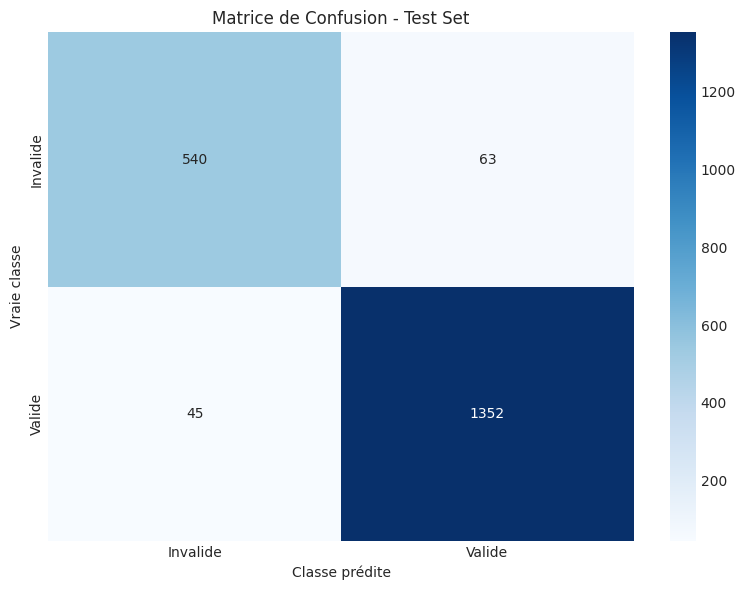

💾 Matrice de confusion sauvegardée dans /workspace/results/validity_classifier_20260104_184906


In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Invalide', 'Valide'],
            yticklabels=['Invalide', 'Valide'])
plt.title('Matrice de Confusion - Test Set')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()

# Sauvegarder
results_dir = RESULTS_DIR / EXPERIMENT_NAME
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Matrice de confusion sauvegardée dans {results_dir}")


### Courbes ROC et Precision-Recall

**Objectif** : Visualiser la qualité des prédictions probabilistes du modèle.

**Ce qu'on fait** :
1. **Courbe ROC (Receiver Operating Characteristic)** :
   - Axe X : Taux de faux positifs (FPR)
   - Axe Y : Taux de vrais positifs (TPR / Recall)
   - Montre la capacité du modèle à distinguer les classes à différents seuils
   - **AUC (Area Under Curve)** : Surface sous la courbe (plus proche de 1 = meilleur)
   - Une courbe au-dessus de la diagonale = meilleur que le hasard

2. **Courbe Precision-Recall** :
   - Axe X : Recall (taux de détection des phrases valides)
   - Axe Y : Precision (qualité des prédictions positives)
   - Montre le compromis entre détecter beaucoup de phrases valides vs être précis
   - Utile quand les classes sont déséquilibrées

**Pourquoi** :
- Permet de choisir le meilleur seuil de décision (actuellement 0.5 par défaut)
- Si AUC est proche de 1, le modèle sépare bien les classes
- Les courbes aident à comprendre les forces/faiblesses du modèle
- Utile pour comparer différents modèles


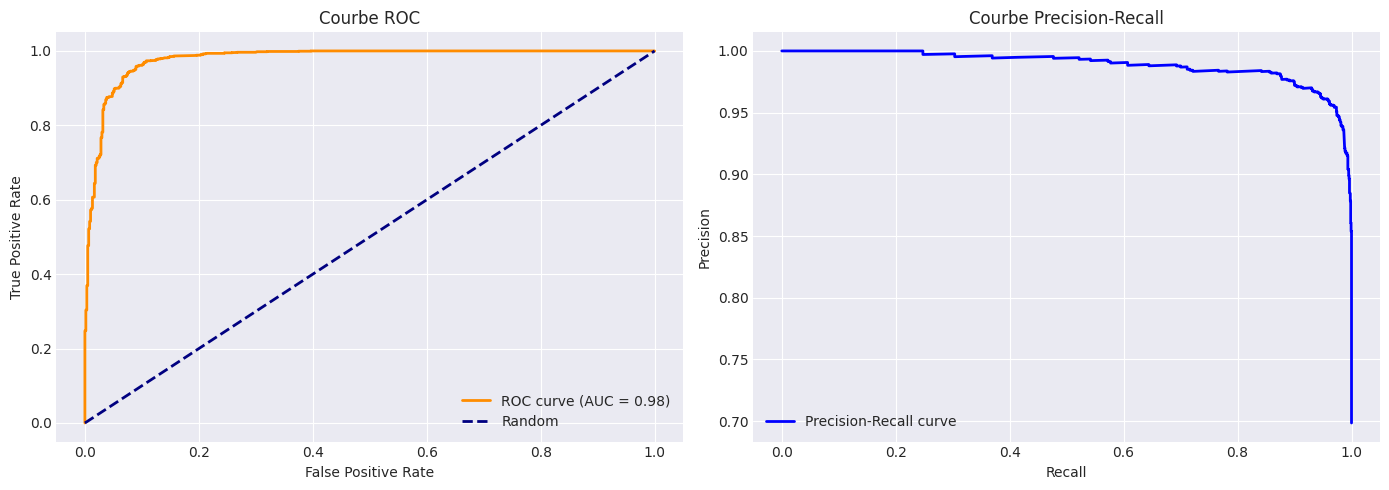

💾 Courbes sauvegardées dans /workspace/results/validity_classifier_20260104_184906


In [11]:
if y_test_proba is not None:
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    
    # Courbe Precision-Recall
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_proba)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Courbe ROC')
    axes[0].legend(loc="lower right")
    axes[0].grid(True)
    
    # Precision-Recall
    axes[1].plot(rec_curve, prec_curve, color='blue', lw=2, label='Precision-Recall curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Courbe Precision-Recall')
    axes[1].legend(loc="lower left")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(results_dir / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 Courbes sauvegardées dans {results_dir}")


### Analyse des erreurs

**Objectif** : Comprendre concrètement pourquoi et quand le modèle se trompe.

**Ce qu'on fait** :
1. **Identifier les erreurs** :
   - **Faux positifs** : Phrases vraiment invalides mais prédites comme valides
   - **Faux négatifs** : Phrases vraiment valides mais prédites comme invalides

2. **Analyser les erreurs** :
   - Afficher des exemples concrets de chaque type d'erreur
   - Montrer la probabilité de confiance du modèle pour chaque erreur
   - Sauvegarder toutes les erreurs dans un fichier CSV pour analyse approfondie

3. **Insights** :
   - Si beaucoup de faux positifs : le modèle est trop permissif
   - Si beaucoup de faux négatifs : le modèle est trop strict
   - Les probabilités proches de 0.5 indiquent des cas ambigus

**Pourquoi** :
- Comprendre les erreurs aide à améliorer le modèle
- Peut révéler des patterns dans les erreurs (ex: le modèle confond certains types de phrases)
- Permet de décider si on a besoin de plus de données d'entraînement pour certains cas
- Utile pour créer un dataset d'erreurs pour réentraîner le modèle (active learning)


In [12]:
# Analyser les erreurs
errors_df = pd.DataFrame({
    'sentence': X_test,
    'true_label': y_test,
    'predicted_label': y_test_pred,
    'probability': y_test_proba if y_test_proba is not None else [None] * len(X_test)
})

# Faux positifs (prédit valide mais invalide)
false_positives = errors_df[(errors_df['true_label'] == 0) & (errors_df['predicted_label'] == 1)]
# Faux négatifs (prédit invalide mais valide)
false_negatives = errors_df[(errors_df['true_label'] == 1) & (errors_df['predicted_label'] == 0)]

print(f"🔍 Analyse des erreurs:")
print(f"   Faux positifs (prédit valide mais invalide): {len(false_positives)}")
print(f"   Faux négatifs (prédit invalide mais valide): {len(false_negatives)}")

if len(false_positives) > 0:
    print(f"\n❌ Exemples de faux positifs (les {min(5, len(false_positives))} premiers):")
    for i, row in false_positives.head(5).iterrows():
        prob = row['probability'] if row['probability'] is not None else 'N/A'
        print(f"   [{prob:.3f}] {row['sentence']}")

if len(false_negatives) > 0:
    print(f"\n❌ Exemples de faux négatifs (les {min(5, len(false_negatives))} premiers):")
    for i, row in false_negatives.head(5).iterrows():
        prob = row['probability'] if row['probability'] is not None else 'N/A'
        print(f"   [{prob:.3f}] {row['sentence']}")

# Sauvegarder les erreurs
errors_df.to_csv(results_dir / 'errors_analysis.csv', index=False, encoding='utf-8')
print(f"\n💾 Analyse des erreurs sauvegardée dans {results_dir / 'errors_analysis.csv'}")


🔍 Analyse des erreurs:
   Faux positifs (prédit valide mais invalide): 63
   Faux négatifs (prédit invalide mais valide): 45

❌ Exemples de faux positifs (les 5 premiers):
   [0.545] 🚆 vers
   [0.773] Patir de Angoulins sur Mer et allé a Poms en voiture
   [0.574] 🚆 Benning-les-Saint-Avold
   [0.500] 🚆 Saint-Christophe-Vallon
   [0.524] 📍 SAINT-PIERRE-SUR-DIVES

❌ Exemples de faux négatifs (les 5 premiers):
   [0.428] Longueau → Longjumeau → Thézy-Glimont
   [0.452] Quel est Le premier Train ranspach Beray ?
   [0.390] Je dois aller à Coutras depuis mantes station
   [0.314] Je dois aller à La Bassée - Violaines depuis Auxerre SaintGervais hein
   [0.409] merci Je véss partir de Ham POUR Givors Canal DIMANCCHE

💾 Analyse des erreurs sauvegardée dans /workspace/results/validity_classifier_20260104_184906/errors_analysis.csv


## 6. Sauvegarde du Modèle Final

**Objectif** : Sauvegarder le modèle entraîné avec toutes ses métadonnées pour pouvoir l'utiliser plus tard en production.

**Ce qu'on fait** :
1. **Préparer les métadonnées** :
   - Nom de l'expérience, version, timestamp
   - Type de modèle et configuration utilisée
   - Paramètres de preprocessing (TF-IDF)
   - Statistiques du dataset (tailles, distributions)
   - Métriques de performance (test et validation)

2. **Sauvegarder** :
   - **Modèle** : Le modèle entraîné (`.joblib`)
   - **Vectorizer** : Le vectorizer TF-IDF (nécessaire pour transformer de nouvelles phrases)
   - **Métadonnées** : Toutes les infos dans un fichier JSON
   - **Métriques** : Résultats dans un CSV pour comparaison future

**Structure des fichiers** :
- `models/baseline/{model_type}_{experiment}_{version}.joblib` : Le modèle
- `models/baseline/vectorizer_{experiment}_{version}.joblib` : Le vectorizer
- `models/baseline/metadata_{experiment}_{version}.json` : Les métadonnées
- `results/{experiment}/metrics.csv` : Les métriques

**Pourquoi** :
- Permet de réutiliser le modèle sans le réentraîner
- Les métadonnées permettent de savoir exactement comment le modèle a été entraîné
- Facilite la comparaison entre différentes expériences
- Nécessaire pour déployer le modèle en production


In [13]:
# Préparer les métadonnées
metadata = {
    'experiment_name': EXPERIMENT_NAME,
    'version': VERSION,
    'timestamp': datetime.now().isoformat(),
    'model_type': MODEL_TYPE,
    'model_config': model_config,
    'preprocessing': {
        'lowercase': LOWERCASE,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'max_features': MAX_FEATURES,
        'ngram_range': list(NGRAM_RANGE)
    },
    'dataset': {
        'total_samples': len(df),
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'class_distribution': {
            'train': {'valid': int(y_train.sum()), 'invalid': int((y_train == 0).sum())},
            'val': {'valid': int(y_val.sum()), 'invalid': int((y_val == 0).sum())},
            'test': {'valid': int(y_test.sum()), 'invalid': int((y_test == 0).sum())}
        }
    },
    'metrics': {
        'test': {
            'accuracy': float(test_acc),
            'precision': float(test_prec),
            'recall': float(test_rec),
            'f1_score': float(test_f1)
        },
        'validation': {
            'accuracy': float(val_acc),
            'precision': float(val_prec),
            'recall': float(val_rec),
            'f1_score': float(val_f1)
        }
    }
}

if y_test_proba is not None:
    metadata['metrics']['test']['roc_auc'] = float(test_auc)

# Sauvegarder le modèle
model_file = MODELS_DIR / f"{MODEL_TYPE}_{EXPERIMENT_NAME}_{VERSION}.joblib"
vectorizer_file = MODELS_DIR / f"vectorizer_{EXPERIMENT_NAME}_{VERSION}.joblib"
metadata_file = MODELS_DIR / f"metadata_{EXPERIMENT_NAME}_{VERSION}.json"

joblib.dump(model, model_file)
joblib.dump(vectorizer, vectorizer_file)

with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"✅ Modèle sauvegardé:")
print(f"   Modèle: {model_file}")
print(f"   Vectorizer: {vectorizer_file}")
print(f"   Métadonnées: {metadata_file}")

# Sauvegarder les métriques dans results
metrics_df = pd.DataFrame([{
    'experiment': EXPERIMENT_NAME,
    'model_type': MODEL_TYPE,
    'test_accuracy': test_acc,
    'test_precision': test_prec,
    'test_recall': test_rec,
    'test_f1': test_f1,
    'test_roc_auc': test_auc if y_test_proba is not None else None,
    'timestamp': datetime.now().isoformat()
}])

metrics_file = results_dir / 'metrics.csv'
metrics_df.to_csv(metrics_file, index=False, encoding='utf-8')
print(f"   Métriques: {metrics_file}")


✅ Modèle sauvegardé:
   Modèle: /workspace/models/baseline/logistic_regression_validity_classifier_20260104_184906_v1.joblib
   Vectorizer: /workspace/models/baseline/vectorizer_validity_classifier_20260104_184906_v1.joblib
   Métadonnées: /workspace/models/baseline/metadata_validity_classifier_20260104_184906_v1.json
   Métriques: /workspace/results/validity_classifier_20260104_184906/metrics.csv


## 7. Test du Modèle Sauvegardé

**Objectif** : Vérifier que le modèle sauvegardé fonctionne correctement et peut être utilisé pour faire des prédictions.

**Ce qu'on fait** :
1. **Recharger le modèle** : Charger le modèle et le vectorizer depuis les fichiers sauvegardés
2. **Tester sur des exemples** : Utiliser le modèle pour prédire sur quelques phrases d'exemple :
   - Phrases valides (ex: "Je vais de Paris à Lyon")
   - Phrases invalides (ex: "Je mange une pomme")
   - Phrases courtes/informelles (ex: "train Marseille Nice demain")
3. **Afficher les résultats** : Montrer la prédiction (valide/invalide) et la probabilité de confiance

**Pourquoi** :
- Vérifie que la sauvegarde/chargement fonctionne correctement
- Montre comment utiliser le modèle en pratique
- Permet de tester rapidement le comportement du modèle sur différents types de phrases
- Confirme que le modèle est prêt à être utilisé en production

**Utilisation future** : Ce modèle peut maintenant être chargé dans une application pour filtrer les phrases avant le traitement NLP.


In [14]:
# Recharger le modèle pour test
loaded_model = joblib.load(model_file)
loaded_vectorizer = joblib.load(vectorizer_file)

# Tester sur quelques phrases
test_sentences = [
    "Je vais de Paris à Lyon",
    "Je mange une pomme",
    "train Marseille Nice demain",
    "Il fait beau aujourd'hui",
    "billet Paris Bordeaux svp"
]

print("🧪 Test du modèle rechargé:")
print("-" * 60)
for sentence in test_sentences:
    # Vectoriser
    sentence_tfidf = loaded_vectorizer.transform([sentence])
    # Prédire
    prediction = loaded_model.predict(sentence_tfidf)[0]
    probability = loaded_model.predict_proba(sentence_tfidf)[0] if hasattr(loaded_model, 'predict_proba') else None
    
    label = "✅ VALIDE" if prediction == 1 else "❌ INVALIDE"
    prob_str = f" (confiance: {probability[1]:.2%})" if probability is not None else ""
    
    print(f"{label}{prob_str}: {sentence}")

print("-" * 60)
print("✅ Modèle fonctionne correctement!")


🧪 Test du modèle rechargé:
------------------------------------------------------------
❌ INVALIDE (confiance: 21.35%): Je vais de Paris à Lyon
❌ INVALIDE (confiance: 12.49%): Je mange une pomme
✅ VALIDE (confiance: 60.66%): train Marseille Nice demain
❌ INVALIDE (confiance: 14.06%): Il fait beau aujourd'hui
❌ INVALIDE (confiance: 32.29%): billet Paris Bordeaux svp
------------------------------------------------------------
✅ Modèle fonctionne correctement!
